In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation

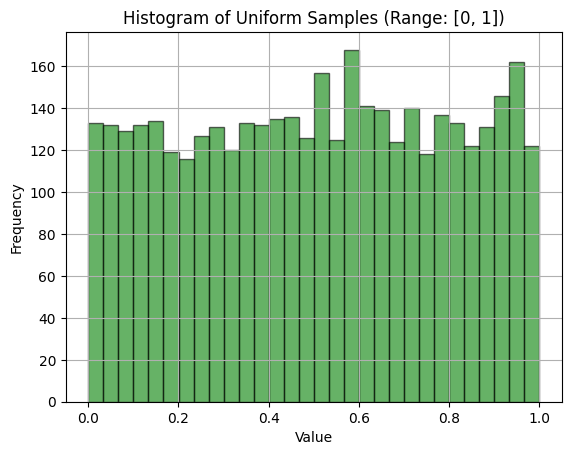

In [2]:
batch_size = 4000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

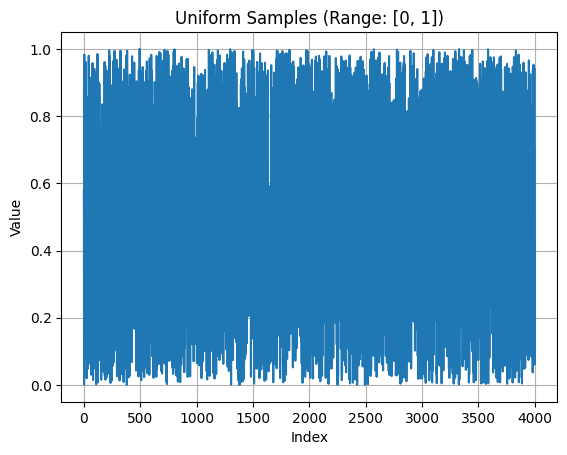

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

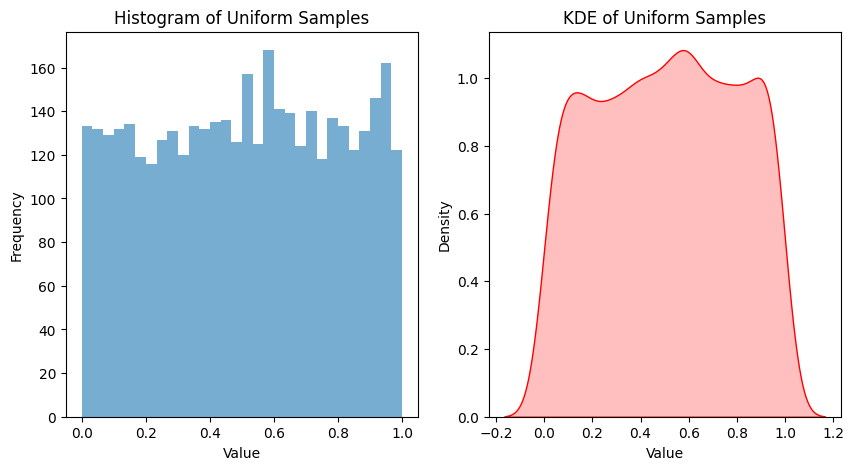

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

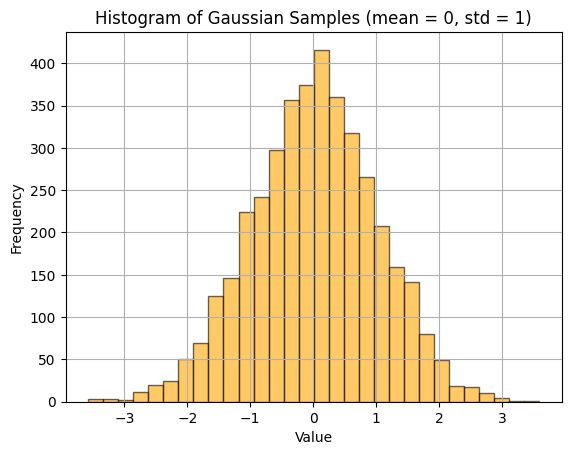

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

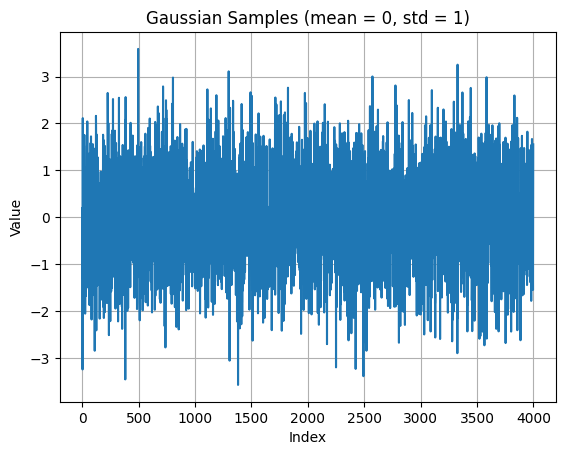

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

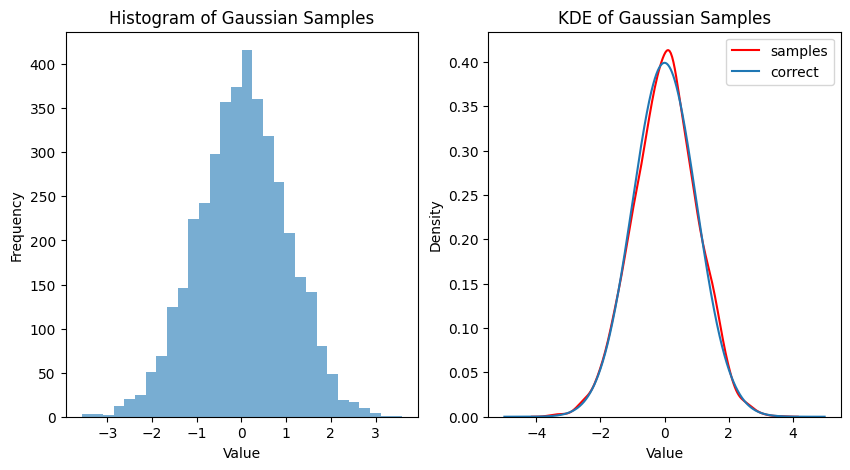

In [7]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

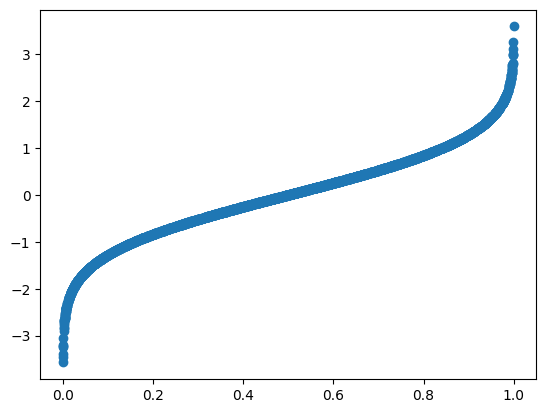

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 128)
        self.fc5 = nn.Linear(128, 128)
        self.fc6 = nn.Linear(128, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples, unbiased=False)
    return variance

In [14]:
def compute_skewness(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    return skewness

In [15]:
def compute_kurtosis(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    return kurtosis

In [16]:
# Initialize the neural network
model = FNN()

In [17]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize lists to store each moment loss over epochs
mean_loss_list = []
variance_loss_list = []
skewness_loss_list = []
kurtosis_loss_list = []
total_loss_list = []
epoch_list = []

# Training loop
num_epochs = 10000
save_interval = 10  # Save model every 10 iterations

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(uniform_samples)
    
    # Compute individual moment losses
    mean_loss = torch.abs(compute_mean(outputs) - compute_mean(gaussian_samples))
    variance_loss = torch.abs(compute_variance(outputs) - compute_variance(gaussian_samples)) 
    skewness_loss = torch.abs(compute_skewness(outputs) - compute_skewness(gaussian_samples))
    kurtosis_loss = torch.abs(compute_kurtosis(outputs) - compute_kurtosis(gaussian_samples))

    # Total loss with weighted moments
    total_loss = (5*mean_loss + 10*variance_loss + skewness_loss + kurtosis_loss)

    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Store each moment loss and epoch number
    mean_loss_list.append(mean_loss.item())
    variance_loss_list.append(variance_loss.item())
    skewness_loss_list.append(skewness_loss.item())
    kurtosis_loss_list.append(kurtosis_loss.item())
    total_loss_list.append(total_loss.item())
    epoch_list.append(epoch + 1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Mean Loss: {mean_loss.item():.5f}, '
          f'Variance Loss: {variance_loss.item():.5f}, Skewness Loss: {skewness_loss.item():.6f}, '
          f'Kurtosis Loss: {kurtosis_loss.item():.6f}')
    
    # Save model every 10 iterations
    if (epoch + 1) % save_interval == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        print(f"Model saved at epoch {epoch+1}")
        
    # Early stopping condition
    if (mean_loss <= 0.005 and variance_loss <= 0.005 and skewness_loss <= 0.01 and 
        kurtosis_loss <= 0.01):
        print(f"Early stopping at epoch {epoch + 1}")
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        break


Epoch [1/10000], Mean Loss: 0.02878, Variance Loss: 0.99294, Skewness Loss: 0.129516, Kurtosis Loss: 1.203345
Epoch [2/10000], Mean Loss: 0.20680, Variance Loss: 0.99312, Skewness Loss: 0.625348, Kurtosis Loss: 0.866558
Epoch [3/10000], Mean Loss: 0.20571, Variance Loss: 0.99311, Skewness Loss: 0.853569, Kurtosis Loss: 0.440275
Epoch [4/10000], Mean Loss: 0.14481, Variance Loss: 0.99316, Skewness Loss: 0.856701, Kurtosis Loss: 0.496603
Epoch [5/10000], Mean Loss: 0.08565, Variance Loss: 0.99320, Skewness Loss: 1.141383, Kurtosis Loss: 0.540319
Epoch [6/10000], Mean Loss: 0.03982, Variance Loss: 0.99292, Skewness Loss: 0.307962, Kurtosis Loss: 1.114487
Epoch [7/10000], Mean Loss: 0.01539, Variance Loss: 0.99209, Skewness Loss: 0.079506, Kurtosis Loss: 1.192265
Epoch [8/10000], Mean Loss: 0.04690, Variance Loss: 0.99097, Skewness Loss: 0.010902, Kurtosis Loss: 1.199717
Epoch [9/10000], Mean Loss: 0.05592, Variance Loss: 0.98977, Skewness Loss: 0.016240, Kurtosis Loss: 1.201137
Epoch [10/

Epoch [78/10000], Mean Loss: 0.08986, Variance Loss: 0.06946, Skewness Loss: 0.021088, Kurtosis Loss: 1.285120
Epoch [79/10000], Mean Loss: 0.04922, Variance Loss: 0.15563, Skewness Loss: 0.009829, Kurtosis Loss: 1.282841
Epoch [80/10000], Mean Loss: 0.03908, Variance Loss: 0.17266, Skewness Loss: 0.017689, Kurtosis Loss: 1.285924
Model saved at epoch 80
Epoch [81/10000], Mean Loss: 0.07317, Variance Loss: 0.13702, Skewness Loss: 0.028918, Kurtosis Loss: 1.289085
Epoch [82/10000], Mean Loss: 0.05783, Variance Loss: 0.04576, Skewness Loss: 0.025146, Kurtosis Loss: 1.293704
Epoch [83/10000], Mean Loss: 0.00757, Variance Loss: 0.11353, Skewness Loss: 0.006285, Kurtosis Loss: 1.299612
Epoch [84/10000], Mean Loss: 0.02557, Variance Loss: 0.18084, Skewness Loss: 0.001155, Kurtosis Loss: 1.302234
Epoch [85/10000], Mean Loss: 0.00183, Variance Loss: 0.14993, Skewness Loss: 0.009139, Kurtosis Loss: 1.302050
Epoch [86/10000], Mean Loss: 0.03909, Variance Loss: 0.03195, Skewness Loss: 0.005497, K

Epoch [156/10000], Mean Loss: 0.06220, Variance Loss: 0.11366, Skewness Loss: 0.015330, Kurtosis Loss: 1.292960
Epoch [157/10000], Mean Loss: 0.04409, Variance Loss: 0.05564, Skewness Loss: 0.008281, Kurtosis Loss: 1.297550
Epoch [158/10000], Mean Loss: 0.01782, Variance Loss: 0.05771, Skewness Loss: 0.014312, Kurtosis Loss: 1.306965
Epoch [159/10000], Mean Loss: 0.02928, Variance Loss: 0.09743, Skewness Loss: 0.018755, Kurtosis Loss: 1.309621
Epoch [160/10000], Mean Loss: 0.00701, Variance Loss: 0.06333, Skewness Loss: 0.006099, Kurtosis Loss: 1.306402
Model saved at epoch 160
Epoch [161/10000], Mean Loss: 0.00768, Variance Loss: 0.02658, Skewness Loss: 0.004807, Kurtosis Loss: 1.301474
Epoch [162/10000], Mean Loss: 0.02934, Variance Loss: 0.04765, Skewness Loss: 0.017111, Kurtosis Loss: 1.301889
Epoch [163/10000], Mean Loss: 0.02684, Variance Loss: 0.01510, Skewness Loss: 0.016450, Kurtosis Loss: 1.303657
Epoch [164/10000], Mean Loss: 0.01257, Variance Loss: 0.07120, Skewness Loss: 0

Epoch [235/10000], Mean Loss: 0.05967, Variance Loss: 0.13500, Skewness Loss: 0.018033, Kurtosis Loss: 1.301279
Epoch [236/10000], Mean Loss: 0.00484, Variance Loss: 0.09534, Skewness Loss: 0.006768, Kurtosis Loss: 1.307800
Epoch [237/10000], Mean Loss: 0.03684, Variance Loss: 0.01445, Skewness Loss: 0.019843, Kurtosis Loss: 1.314176
Epoch [238/10000], Mean Loss: 0.03699, Variance Loss: 0.11690, Skewness Loss: 0.021403, Kurtosis Loss: 1.321720
Epoch [239/10000], Mean Loss: 0.00249, Variance Loss: 0.17648, Skewness Loss: 0.007515, Kurtosis Loss: 1.323380
Epoch [240/10000], Mean Loss: 0.01176, Variance Loss: 0.16335, Skewness Loss: 0.003923, Kurtosis Loss: 1.322306
Model saved at epoch 240
Epoch [241/10000], Mean Loss: 0.00589, Variance Loss: 0.08761, Skewness Loss: 0.009498, Kurtosis Loss: 1.319091
Epoch [242/10000], Mean Loss: 0.01595, Variance Loss: 0.03531, Skewness Loss: 0.000241, Kurtosis Loss: 1.310927
Epoch [243/10000], Mean Loss: 0.00031, Variance Loss: 0.08827, Skewness Loss: 0

Epoch [311/10000], Mean Loss: 0.05200, Variance Loss: 0.02707, Skewness Loss: 0.020095, Kurtosis Loss: 1.310110
Epoch [312/10000], Mean Loss: 0.02873, Variance Loss: 0.01701, Skewness Loss: 0.011156, Kurtosis Loss: 1.312362
Epoch [313/10000], Mean Loss: 0.02746, Variance Loss: 0.04422, Skewness Loss: 0.010915, Kurtosis Loss: 1.319213
Epoch [314/10000], Mean Loss: 0.04333, Variance Loss: 0.04292, Skewness Loss: 0.016935, Kurtosis Loss: 1.319852
Epoch [315/10000], Mean Loss: 0.02269, Variance Loss: 0.01368, Skewness Loss: 0.008472, Kurtosis Loss: 1.315566
Epoch [316/10000], Mean Loss: 0.02170, Variance Loss: 0.01722, Skewness Loss: 0.008419, Kurtosis Loss: 1.312782
Epoch [317/10000], Mean Loss: 0.02790, Variance Loss: 0.03145, Skewness Loss: 0.010108, Kurtosis Loss: 1.315265
Epoch [318/10000], Mean Loss: 0.00796, Variance Loss: 0.02498, Skewness Loss: 0.002637, Kurtosis Loss: 1.316113
Epoch [319/10000], Mean Loss: 0.03485, Variance Loss: 0.03059, Skewness Loss: 0.012928, Kurtosis Loss: 1

...

Epoch [6667/10000], Mean Loss: 0.00691, Variance Loss: 0.01155, Skewness Loss: 0.008884, Kurtosis Loss: 0.002325
Epoch [6668/10000], Mean Loss: 0.04374, Variance Loss: 0.04892, Skewness Loss: 0.016946, Kurtosis Loss: 0.028022
Epoch [6669/10000], Mean Loss: 0.05688, Variance Loss: 0.06797, Skewness Loss: 0.008580, Kurtosis Loss: 0.028850
Epoch [6670/10000], Mean Loss: 0.03724, Variance Loss: 0.05195, Skewness Loss: 0.013455, Kurtosis Loss: 0.008228
Model saved at epoch 6670
Epoch [6671/10000], Mean Loss: 0.00728, Variance Loss: 0.00277, Skewness Loss: 0.035278, Kurtosis Loss: 0.027635
Epoch [6672/10000], Mean Loss: 0.01982, Variance Loss: 0.07655, Skewness Loss: 0.035534, Kurtosis Loss: 0.065991
Epoch [6673/10000], Mean Loss: 0.00008, Variance Loss: 0.11013, Skewness Loss: 0.021560, Kurtosis Loss: 0.081164
Epoch [6674/10000], Mean Loss: 0.04871, Variance Loss: 0.09825, Skewness Loss: 0.005031, Kurtosis Loss: 0.074718
Epoch [6675/10000], Mean Loss: 0.06567, Variance Loss: 0.04796, Skewne

Epoch [6746/10000], Mean Loss: 0.02744, Variance Loss: 0.08177, Skewness Loss: 0.022779, Kurtosis Loss: 0.052480
Epoch [6747/10000], Mean Loss: 0.03455, Variance Loss: 0.04658, Skewness Loss: 0.016173, Kurtosis Loss: 0.025255
Epoch [6748/10000], Mean Loss: 0.00851, Variance Loss: 0.02481, Skewness Loss: 0.009471, Kurtosis Loss: 0.016343
Epoch [6749/10000], Mean Loss: 0.04915, Variance Loss: 0.04457, Skewness Loss: 0.039884, Kurtosis Loss: 0.028316
Epoch [6750/10000], Mean Loss: 0.06915, Variance Loss: 0.02772, Skewness Loss: 0.047618, Kurtosis Loss: 0.022318
Model saved at epoch 6750
Epoch [6751/10000], Mean Loss: 0.05639, Variance Loss: 0.02336, Skewness Loss: 0.035578, Kurtosis Loss: 0.000243
Epoch [6752/10000], Mean Loss: 0.00315, Variance Loss: 0.02613, Skewness Loss: 0.003474, Kurtosis Loss: 0.005749
Epoch [6753/10000], Mean Loss: 0.08110, Variance Loss: 0.01177, Skewness Loss: 0.042491, Kurtosis Loss: 0.032360
Epoch [6754/10000], Mean Loss: 0.11210, Variance Loss: 0.00414, Skewne

Epoch [6826/10000], Mean Loss: 0.06466, Variance Loss: 0.07390, Skewness Loss: 0.032282, Kurtosis Loss: 0.019753
Epoch [6827/10000], Mean Loss: 0.05433, Variance Loss: 0.03575, Skewness Loss: 0.019241, Kurtosis Loss: 0.013116
Epoch [6828/10000], Mean Loss: 0.01890, Variance Loss: 0.03015, Skewness Loss: 0.003791, Kurtosis Loss: 0.053757
Epoch [6829/10000], Mean Loss: 0.03346, Variance Loss: 0.05692, Skewness Loss: 0.030492, Kurtosis Loss: 0.074257
Epoch [6830/10000], Mean Loss: 0.05360, Variance Loss: 0.04442, Skewness Loss: 0.041070, Kurtosis Loss: 0.073552
Model saved at epoch 6830
Epoch [6831/10000], Mean Loss: 0.04481, Variance Loss: 0.00151, Skewness Loss: 0.037126, Kurtosis Loss: 0.055095
Epoch [6832/10000], Mean Loss: 0.01274, Variance Loss: 0.01180, Skewness Loss: 0.016459, Kurtosis Loss: 0.045134
Epoch [6833/10000], Mean Loss: 0.03950, Variance Loss: 0.00862, Skewness Loss: 0.019341, Kurtosis Loss: 0.041172
Epoch [6834/10000], Mean Loss: 0.06335, Variance Loss: 0.00600, Skewne

Epoch [6906/10000], Mean Loss: 0.03086, Variance Loss: 0.00338, Skewness Loss: 0.013282, Kurtosis Loss: 0.008529
Epoch [6907/10000], Mean Loss: 0.01432, Variance Loss: 0.04034, Skewness Loss: 0.022951, Kurtosis Loss: 0.035254
Epoch [6908/10000], Mean Loss: 0.02913, Variance Loss: 0.04795, Skewness Loss: 0.018336, Kurtosis Loss: 0.039612
Epoch [6909/10000], Mean Loss: 0.01675, Variance Loss: 0.02356, Skewness Loss: 0.001331, Kurtosis Loss: 0.023764
Epoch [6910/10000], Mean Loss: 0.02015, Variance Loss: 0.03183, Skewness Loss: 0.026659, Kurtosis Loss: 0.008903
Model saved at epoch 6910
Epoch [6911/10000], Mean Loss: 0.02790, Variance Loss: 0.04789, Skewness Loss: 0.038862, Kurtosis Loss: 0.019424
Epoch [6912/10000], Mean Loss: 0.00933, Variance Loss: 0.02687, Skewness Loss: 0.037080, Kurtosis Loss: 0.011124
Epoch [6913/10000], Mean Loss: 0.03259, Variance Loss: 0.02565, Skewness Loss: 0.023417, Kurtosis Loss: 0.014297
Epoch [6914/10000], Mean Loss: 0.04773, Variance Loss: 0.03961, Skewne

Epoch [6985/10000], Mean Loss: 0.07380, Variance Loss: 0.00938, Skewness Loss: 0.042915, Kurtosis Loss: 0.046403
Epoch [6986/10000], Mean Loss: 0.02292, Variance Loss: 0.04259, Skewness Loss: 0.019864, Kurtosis Loss: 0.011359
Epoch [6987/10000], Mean Loss: 0.05085, Variance Loss: 0.05692, Skewness Loss: 0.020258, Kurtosis Loss: 0.011419
Epoch [6988/10000], Mean Loss: 0.08700, Variance Loss: 0.03234, Skewness Loss: 0.041839, Kurtosis Loss: 0.011112
Epoch [6989/10000], Mean Loss: 0.08778, Variance Loss: 0.02344, Skewness Loss: 0.045904, Kurtosis Loss: 0.006594
Epoch [6990/10000], Mean Loss: 0.05817, Variance Loss: 0.03902, Skewness Loss: 0.032063, Kurtosis Loss: 0.005005
Model saved at epoch 6990
Epoch [6991/10000], Mean Loss: 0.00694, Variance Loss: 0.02154, Skewness Loss: 0.004634, Kurtosis Loss: 0.011929
Epoch [6992/10000], Mean Loss: 0.06004, Variance Loss: 0.02369, Skewness Loss: 0.034515, Kurtosis Loss: 0.033810
Epoch [6993/10000], Mean Loss: 0.09007, Variance Loss: 0.03028, Skewne

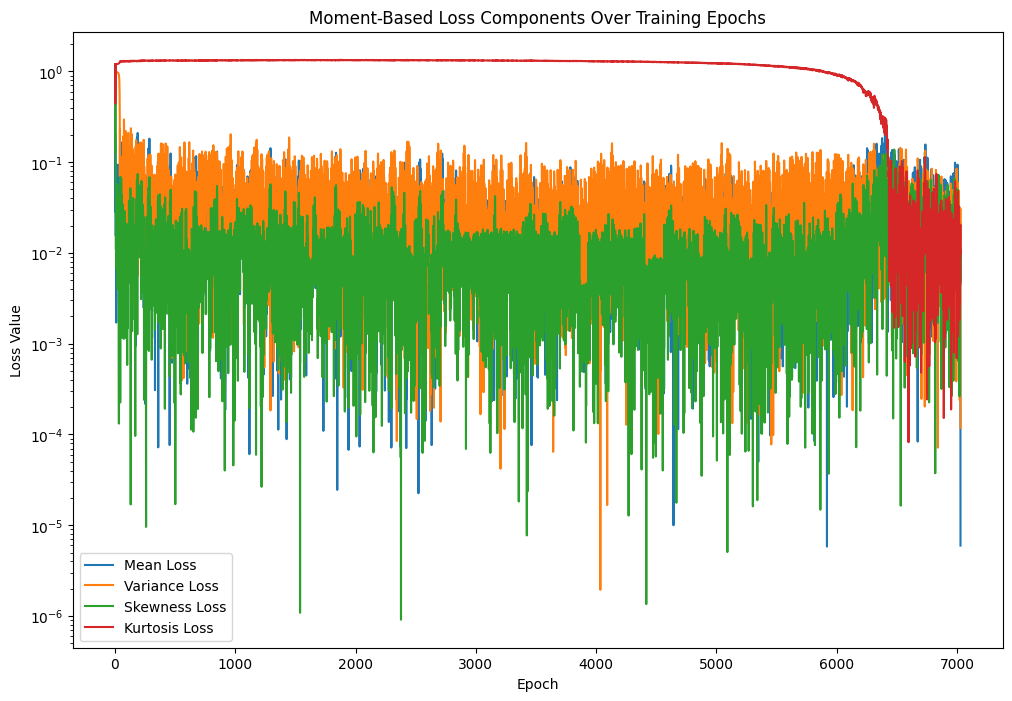

In [18]:
# Plot each loss component
plt.figure(figsize=(12, 8))
plt.yscale('log')
plt.plot(epoch_list, mean_loss_list, label="Mean Loss")
plt.plot(epoch_list, variance_loss_list, label="Variance Loss")
plt.plot(epoch_list, skewness_loss_list, label="Skewness Loss")
plt.plot(epoch_list, kurtosis_loss_list, label="Kurtosis Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Moment-Based Loss Components Over Training Epochs")
plt.legend()
plt.show()

Text(0, 0.5, '$l_2$')

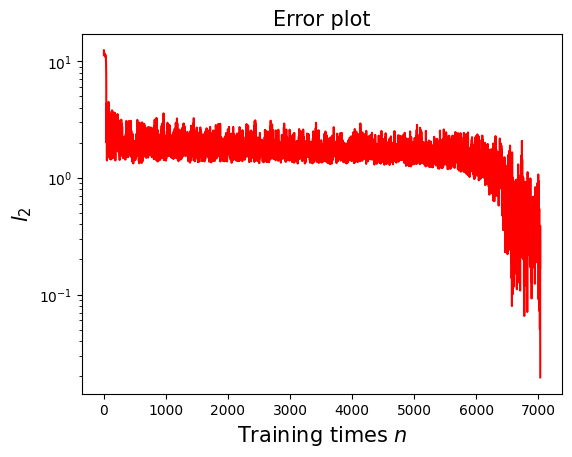

In [19]:
fig = plt.figure(1)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
plt.title("Error plot",fontsize=15) 
plt.yscale('log')
plt.plot(epoch_list, total_loss_list,'r',label='Training error')
plt.xlabel(r'Training times $n$',fontsize=15)
plt.ylabel(r'$l_2$',fontsize=15)

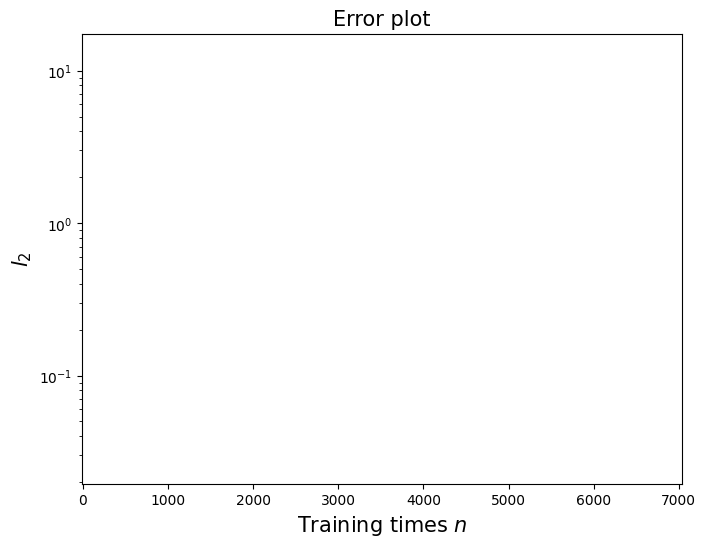

In [20]:
# Initialize figure
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
ax.set_title("Error plot", fontsize=15)
ax.set_xlabel(r'Training times $n$', fontsize=15)
ax.set_ylabel(r'$l_2$', fontsize=15)
ax.set_yscale('log')  # Use logarithmic scale for better visualization
ax.set_xlim(-10, epoch_list[-1]+10)  # Initial x-axis limit
ax.set_ylim(min(total_loss_list)-0.00001, max(total_loss_list)+5)  # Set y-axis limit

# Initialize line plot object (empty initially)
line, = ax.plot([], [], 'r', label='Training error')

# Function to update the plot in the animation
def update_plot(frame):
    # Show 10 more points at each frame
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    
    # Update the line data
    line.set_data(epoch_data, loss_data)
    
    # Update the title to reflect the current epoch range
    ax.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    
    return line,

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=500, repeat=False)

# Show the animation
plt.show()

# Optionally save the animation as a GIF
anim.save("error_plot_animation.gif", writer="pillow", fps=2)


In [21]:
from matplotlib.animation import FuncAnimation

# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [22]:
# Function to load model and transform samples
def load_and_transform(model, model_path, input_test):
    model.load_state_dict(torch.load(model_path))
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        transformed_samples = model(input_test)
    return transformed_samples.numpy()

In [23]:
# Get list of saved models sorted by creation time
model_files = sorted(glob.glob("model_epoch_*.pt"), key=os.path.getmtime)

if not model_files:
    print("No model files found.")
else:
    # Collect transformed samples for each saved model
    transformed_samples_list = [load_and_transform(model, path, input_test) for path in model_files]

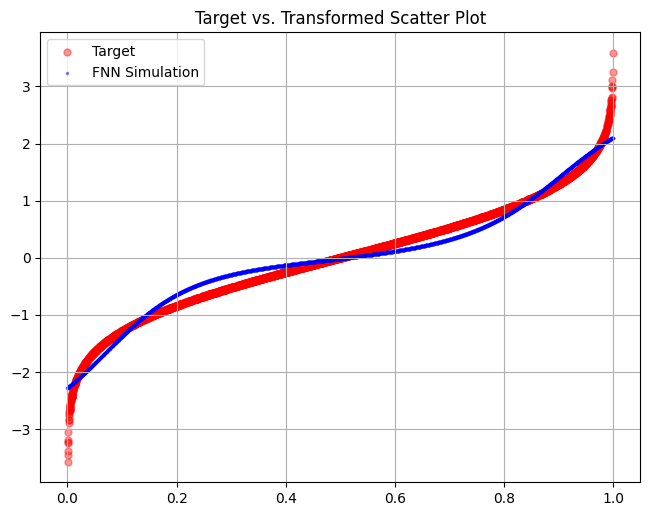

In [24]:
# Set up the figure with two subplots
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])

# Scatter plot
scatter_target = ax.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax.legend()
ax.set_title("Target vs. Transformed Scatter Plot")
ax.grid(True)


In [25]:
# Animation function
def animate(i):
    # Update scatter plot for FNN simulation
    epoch = int(model_files[i].split('_')[-1].split('.')[0])
    scatter_sim.set_offsets(np.c_[1-input_test.numpy(), transformed_samples_list[i]])
    ax.set_title(f"Scatter Plot at Epoch {epoch}")

In [26]:
# Create the animation
anim = FuncAnimation(fig, animate, frames=len(transformed_samples_list), interval=50)
%matplotlib inline
# Display the animation
plt.show()
# Save animation
anim.save("training_animation.gif", writer="pillow", fps=20)

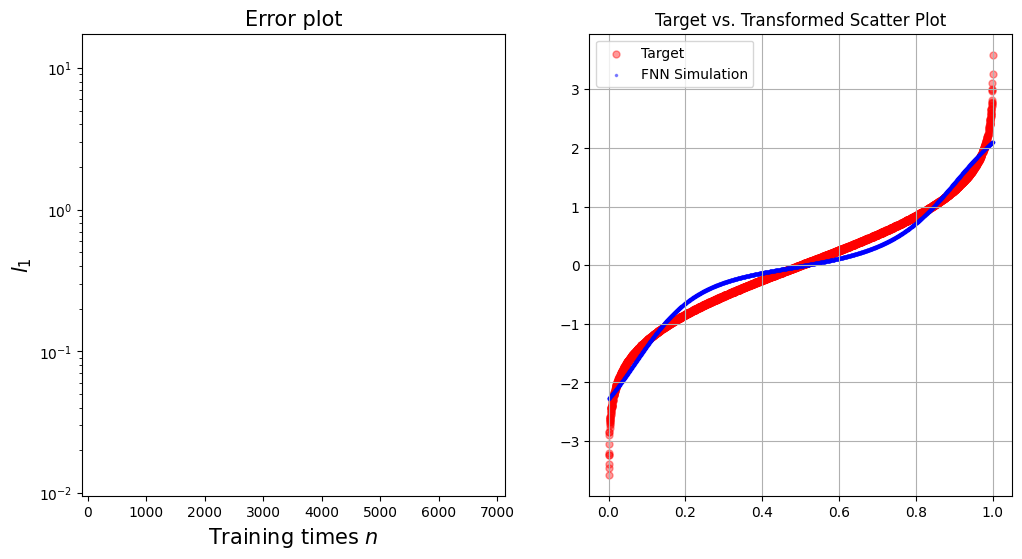

In [35]:
# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Total loss plot (ax1)
ax1.set_title("Error plot", fontsize=15)
ax1.set_xlabel(r'Training times $n$', fontsize=15)
ax1.set_ylabel(r'$l_1$', fontsize=15)
ax1.set_yscale('log')  # Use logarithmic scale for better visualization
ax1.set_xlim(-100, epoch_list[-1]+100)  # Initial x-axis limit
ax1.set_ylim(min(total_loss_list)-0.01, max(total_loss_list)+5)  # Set y-axis limit
line, = ax1.plot([], [], 'r', label='Training error')

# Scatter plot (ax2)
scatter_target = ax2.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax2.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax2.legend()
ax2.set_title("Target vs. Transformed Scatter Plot")
ax2.grid(True)

# Function to update both the total loss plot and scatter plot
def update_plot(frame):
    # Update total loss plot (ax1)
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    line.set_data(epoch_data, loss_data)
    
    # Update scatter plot (ax2) for FNN simulation
    scatter_sim.set_offsets(np.c_[1-input_test.numpy(), transformed_samples_list[frame]])
    
    # Update titles
    ax1.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    ax2.set_title(f"Scatter Plot at Epoch {frame * 10}", fontsize=15)
    
    return line, scatter_sim  # Return the updated plot elements

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the combined animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=50, repeat=False)

# Show the animation
plt.show()

# Optionally, save the animation as a GIF
anim.save("combined_training_animation.gif", writer="pillow", fps=20)

In [28]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

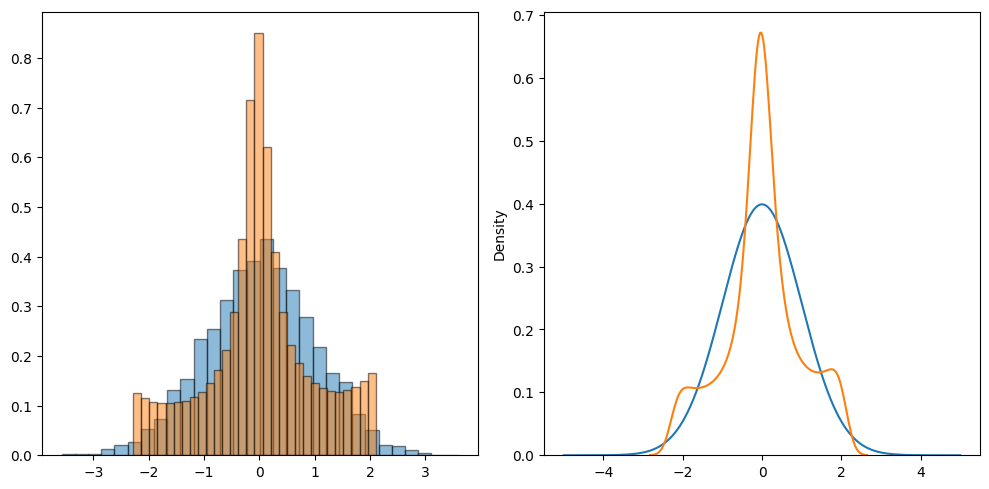

In [29]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

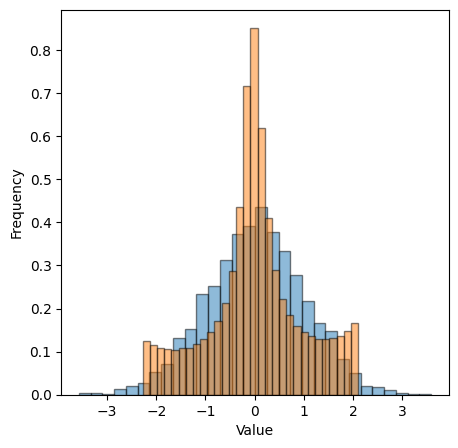

In [30]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

Text(0.5, 0, 'Value')

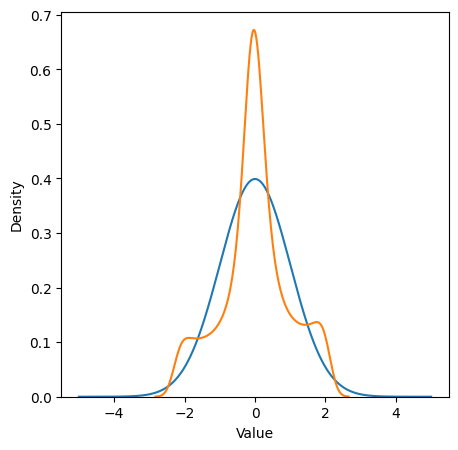

In [31]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')

In [32]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples1 = model(uniform_samples)


print(compute_mean(transformed_samples1))
print(compute_variance(transformed_samples1))
print(compute_skewness(transformed_samples1))
print(compute_kurtosis(transformed_samples1))

tensor(-0.0160)
tensor(0.9352)
tensor(-0.0486)
tensor(0.0052)


In [33]:
print(compute_mean(gaussian_samples))
print(compute_variance(gaussian_samples))
print(compute_skewness(gaussian_samples))
print(compute_kurtosis(gaussian_samples))

tensor(0.0179, dtype=torch.float64)
tensor(0.9932, dtype=torch.float64)
tensor(-0.0592, dtype=torch.float64)
tensor(-0.0064, dtype=torch.float64)
